#ResNet Pipeline
## Goals
- Load the standardized preprocessed dataset
- Compare `ResNet-18` and `ResNet-50` frozen feature extractors
- Train simple downstream classifiers on those features
- Visualize the learned feature space with PCA and t-SNE
- Save features and evaluation results in an isolated output folder

In [1]:
from pathlib import Path
import json
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torchvision import models

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

ROOT = Path.cwd()
DATA_DIR = ROOT / 'tumor_data'
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Testing'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_DIR = ROOT / 'outputs' / 'amanda_resnet'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATHS = {
    'resnet18': OUTPUT_DIR / 'resnet18_features.npz',
    'resnet50': OUTPUT_DIR / 'resnet50_features.npz',
}
RESULTS_PATH = OUTPUT_DIR / 'classification_results.json'
PLOT_PATH = OUTPUT_DIR / 'feature_space_plots.png'

IMG_SIZE = 224
VAL_FRACTION = 0.2
RANDOM_SEED = 42
APPLY_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = (8, 8)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

print(f'Project root: {ROOT}')
print(f'Processed data dir: {PROCESSED_DIR}')
print(f'Output dir: {OUTPUT_DIR}')
print(f'Device: {DEVICE}')

Project root: /Users/amandachung/281_final_proj
Processed data dir: /Users/amandachung/281_final_proj/tumor_data/processed
Output dir: /Users/amandachung/281_final_proj/outputs/amanda_resnet
Device: mps


In [2]:
required_files = {
    'train': PROCESSED_DIR / 'train.npz',
    'val': PROCESSED_DIR / 'val.npz',
    'test': PROCESSED_DIR / 'test.npz',
    'class_mapping': PROCESSED_DIR / 'class_mapping.npy',
}

missing = [name for name, path in required_files.items() if not path.exists()]

if missing:
    print(f'Missing processed files: {missing}')
    print('Rebuilding processed dataset from tumor_data/Training and tumor_data/Testing...')

    if not TRAIN_DIR.exists() or not TEST_DIR.exists():
        raise FileNotFoundError(
            'Could not find raw dataset folders. Expected:\n'
            f'  {TRAIN_DIR}\n'
            f'  {TEST_DIR}'
        )

    classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
    class_to_idx = {cls: i for i, cls in enumerate(classes)}

    def load_and_preprocess(filepath, img_size=IMG_SIZE, apply_clahe=APPLY_CLAHE):
        img = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f'Could not read image: {filepath}')

        h, w = img.shape
        interp = cv2.INTER_AREA if (h > img_size or w > img_size) else cv2.INTER_LINEAR
        img = cv2.resize(img, (img_size, img_size), interpolation=interp)

        if apply_clahe:
            clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
            img = clahe.apply(img)

        return img

    def load_dataset(base_dir):
        images, labels = [], []
        for cls in classes:
            folder = base_dir / cls
            filepaths = sorted([
                f for f in folder.iterdir()
                if f.is_file() and f.suffix.lower() in ('.jpg', '.jpeg', '.png')
            ])
            for fpath in filepaths:
                img = load_and_preprocess(fpath)
                images.append(img)
                labels.append(class_to_idx[cls])
        return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int32)

    X_train_full, y_train_full = load_dataset(TRAIN_DIR)
    X_test_raw, y_test_raw = load_dataset(TEST_DIR)

    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_full,
        y_train_full,
        test_size=VAL_FRACTION,
        random_state=RANDOM_SEED,
        stratify=y_train_full,
    )

    np.savez_compressed(required_files['train'], images=X_train_raw, labels=y_train_raw)
    np.savez_compressed(required_files['val'], images=X_val_raw, labels=y_val_raw)
    np.savez_compressed(required_files['test'], images=X_test_raw, labels=y_test_raw)
    np.save(required_files['class_mapping'], class_to_idx)

    print('Rebuilt processed dataset files:')
    for name, path in required_files.items():
        print(f'  {name}: {path}')

train = np.load(required_files['train'])
val = np.load(required_files['val'])
test = np.load(required_files['test'])
CLASS_TO_IDX = np.load(required_files['class_mapping'], allow_pickle=True).item()
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}
CLASSES = [IDX_TO_CLASS[i] for i in range(len(IDX_TO_CLASS))]

X_train, y_train = train['images'], train['labels']
X_val, y_val = val['images'], val['labels']
X_test, y_test = test['images'], test['labels']

print(f'Train: {X_train.shape}, labels: {y_train.shape}')
print(f'Val:   {X_val.shape}, labels: {y_val.shape}')
print(f'Test:  {X_test.shape}, labels: {y_test.shape}')
print(f'Classes: {CLASSES}')
print(f'Dtype: {X_train.dtype}, min={X_train.min()}, max={X_train.max()}')

Train: (4480, 224, 224), labels: (4480,)
Val:   (1120, 224, 224), labels: (1120,)
Test:  (1600, 224, 224), labels: (1600,)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Dtype: uint8, min=0, max=255


## ResNet Feature Extraction

The shared preprocessing pipeline stores images as grayscale arrays. To use pretrained ImageNet backbones, this notebook:

- converts grayscale images to 3-channel inputs
- rescales to `[0, 1]` if needed
- applies ImageNet normalization
- removes the final classification layer and keeps the pooled feature vector
- compares both `ResNet-18` and `ResNet-50` on the same shared dataset

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

BACKBONES = {
    'resnet18': {
        'builder': lambda: models.resnet18(weights=models.ResNet18_Weights.DEFAULT),
        'feature_dim': 512,
    },
    'resnet50': {
        'builder': lambda: models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
        'feature_dim': 2048,
    },
}

def preprocess_for_resnet(images):
    """Convert grayscale arrays into normalized 3-channel tensors for ResNet."""
    images = images.astype(np.float32)
    if images.max() > 1.5:
        images = images / 255.0
    images = np.clip(images, 0.0, 1.0)
    images = np.stack([images] * 3, axis=-1)
    images = (images - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(images).permute(0, 3, 1, 2).float()

def build_feature_extractor(backbone_name):
    model = BACKBONES[backbone_name]['builder']()
    extractor = nn.Sequential(*list(model.children())[:-1]).to(DEVICE)
    extractor.eval()
    return extractor

def extract_backbone_features(images, backbone_name, batch_size=64):
    extractor = build_feature_extractor(backbone_name)
    features = []
    start_time = time.time()

    with torch.no_grad():
        for start_idx in range(0, len(images), batch_size):
            end_idx = start_idx + batch_size
            batch = preprocess_for_resnet(images[start_idx:end_idx]).to(DEVICE)
            batch_features = extractor(batch).flatten(1).cpu().numpy()
            features.append(batch_features)

    features = np.concatenate(features, axis=0)
    elapsed = time.time() - start_time
    print(
        f'{backbone_name}: extracted {features.shape[0]} samples in {elapsed:.1f}s '
        f'-> feature dim {features.shape[1]}'
    )
    return features

for backbone_name, config in BACKBONES.items():
    print(f'{backbone_name} ready (feature dim={config["feature_dim"]})')

resnet18 ready (feature dim=512)
resnet50 ready (feature dim=2048)


In [4]:
features_by_backbone = {}

for backbone_name, feature_path in FEATURE_PATHS.items():
    if feature_path.exists():
        cached = np.load(feature_path)
        train_features = cached['train']
        val_features = cached['val']
        test_features = cached['test']
        print(f'Loaded cached {backbone_name} features from {feature_path}')
    else:
        train_features = extract_backbone_features(X_train, backbone_name)
        val_features = extract_backbone_features(X_val, backbone_name)
        test_features = extract_backbone_features(X_test, backbone_name)
        np.savez_compressed(
            feature_path,
            train=train_features,
            val=val_features,
            test=test_features,
            y_train=y_train,
            y_val=y_val,
            y_test=y_test,
        )
        print(f'Saved {backbone_name} features to {feature_path}')

    features_by_backbone[backbone_name] = {
        'train': train_features,
        'val': val_features,
        'test': test_features,
    }

for backbone_name, split_features in features_by_backbone.items():
    print(f'\n{backbone_name}:')
    print(f'  train -> {split_features["train"].shape}')
    print(f'  val   -> {split_features["val"].shape}')
    print(f'  test  -> {split_features["test"].shape}')

Loaded cached resnet18 features from /Users/amandachung/281_final_proj/outputs/amanda_resnet/resnet18_features.npz
Loaded cached resnet50 features from /Users/amandachung/281_final_proj/outputs/amanda_resnet/resnet50_features.npz

resnet18:
  train -> (4480, 512)
  val   -> (1120, 512)
  test  -> (1600, 512)

resnet50:
  train -> (4480, 2048)
  val   -> (1120, 2048)
  test  -> (1600, 2048)


In [5]:
models_to_run = {
    'svm_rbf': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10.0, gamma='scale')),
    ]),
    'logreg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000)),
    ]),
}

results = {}
trained_models = {}
summary_rows = []

for backbone_name, split_features in features_by_backbone.items():
    results[backbone_name] = {}
    X_train_feat = split_features['train']
    X_val_feat = split_features['val']
    X_test_feat = split_features['test']

    for model_name, model in models_to_run.items():
        model_instance = clone(model)
        fit_start = time.time()
        model_instance.fit(X_train_feat, y_train)
        fit_time = time.time() - fit_start

        y_val_pred = model_instance.predict(X_val_feat)
        y_test_pred = model_instance.predict(X_test_feat)

        val_acc = accuracy_score(y_val, y_val_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        results[backbone_name][model_name] = {
            'val_accuracy': float(val_acc),
            'test_accuracy': float(test_acc),
            'fit_time_sec': float(fit_time),
            'classification_report': classification_report(
                y_test,
                y_test_pred,
                target_names=CLASSES,
                output_dict=True,
                zero_division=0,
            ),
        }
        trained_models[(backbone_name, model_name)] = model_instance
        summary_rows.append((backbone_name, model_name, val_acc, test_acc, fit_time))

        print(
            f'{backbone_name} + {model_name}: '
            f'val_acc={val_acc:.4f}, test_acc={test_acc:.4f}, fit_time={fit_time:.2f}s'
        )

with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2)

print(f'Saved metrics to {RESULTS_PATH}')
sorted(summary_rows, key=lambda row: row[2], reverse=True)

resnet18 + svm_rbf: val_acc=0.9536, test_acc=0.9169, fit_time=1.07s
resnet18 + logreg: val_acc=0.8973, test_acc=0.8594, fit_time=0.19s


/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn

resnet50 + svm_rbf: val_acc=0.9366, test_acc=0.9006, fit_time=8.15s


/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn

resnet50 + logreg: val_acc=0.9286, test_acc=0.8956, fit_time=0.30s
Saved metrics to /Users/amandachung/281_final_proj/outputs/amanda_resnet/classification_results.json


/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[('resnet18', 'svm_rbf', 0.9535714285714286, 0.916875, 1.0701665878295898),
 ('resnet50', 'svm_rbf', 0.9366071428571429, 0.900625, 8.148334264755249),
 ('resnet50', 'logreg', 0.9285714285714286, 0.895625, 0.2967519760131836),
 ('resnet18', 'logreg', 0.8973214285714286, 0.859375, 0.18797993659973145)]

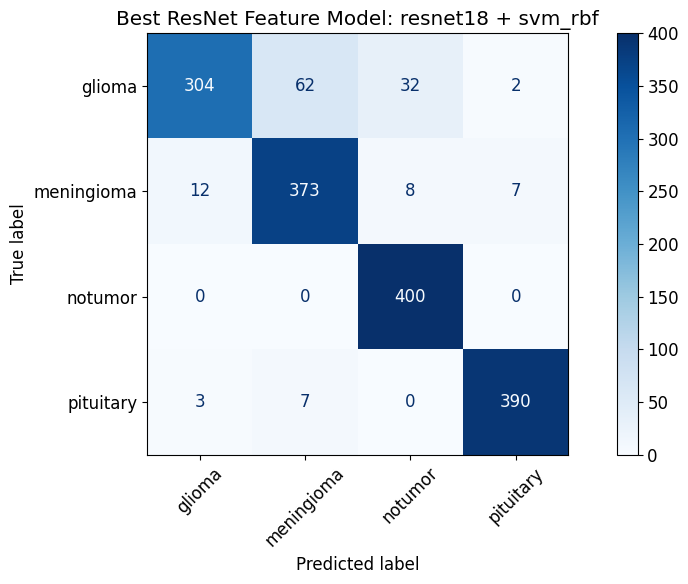

Best model by validation accuracy: resnet18 + svm_rbf
              precision    recall  f1-score   support

      glioma       0.95      0.76      0.85       400
  meningioma       0.84      0.93      0.89       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.98      0.97      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [6]:
best_backbone_name = None
best_model_name = None
best_val_acc = -1.0

for backbone_name, backbone_results in results.items():
    for model_name, metrics in backbone_results.items():
        if metrics['val_accuracy'] > best_val_acc:
            best_val_acc = metrics['val_accuracy']
            best_backbone_name = backbone_name
            best_model_name = model_name

best_model = trained_models[(best_backbone_name, best_model_name)]
best_test_pred = best_model.predict(features_by_backbone[best_backbone_name]['test'])

cm = confusion_matrix(y_test, best_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title(f'Best ResNet Feature Model: {best_backbone_name} + {best_model_name}')
plt.tight_layout()
plt.show()

print(f'Best model by validation accuracy: {best_backbone_name} + {best_model_name}')
print(classification_report(y_test, best_test_pred, target_names=CLASSES, zero_division=0))

## PCA and t-SNE Visualization

These plots project the validation-set features into 2D so you can inspect how well the best backbone separates the tumor classes in feature space.

/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/amandachung/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul

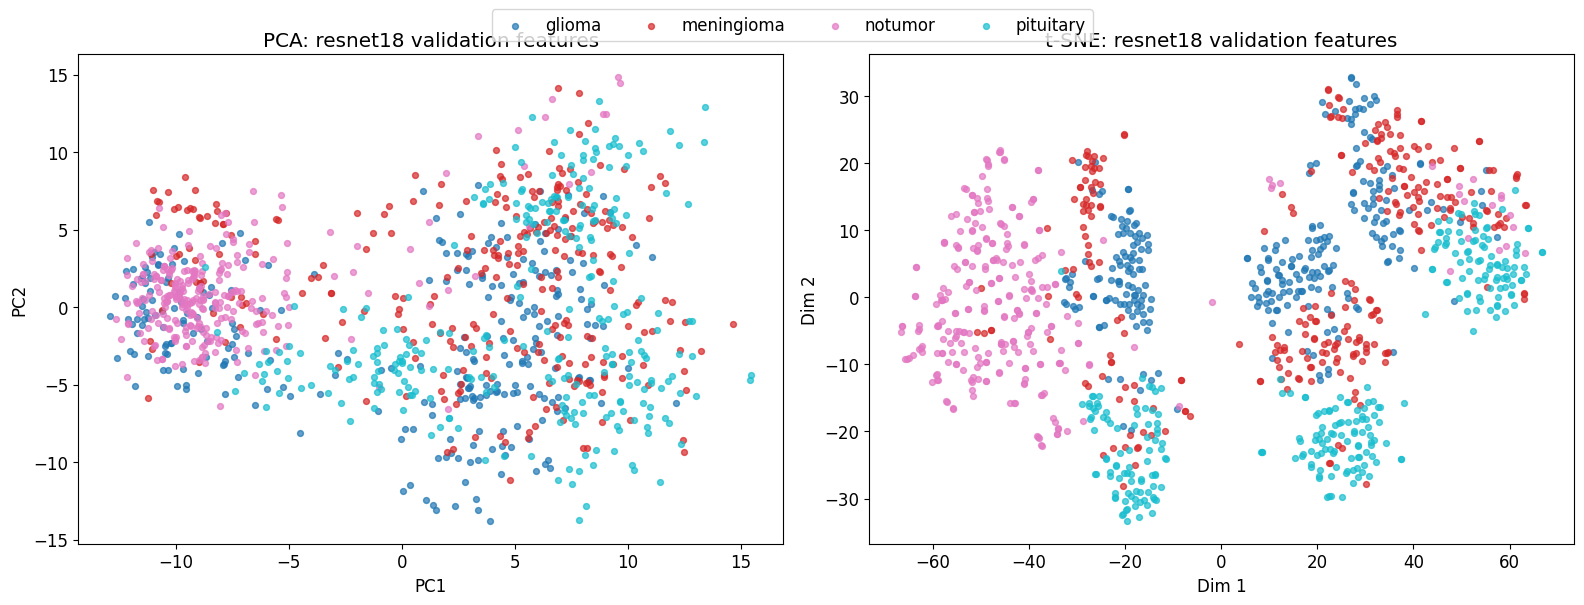

Saved feature-space plots to /Users/amandachung/281_final_proj/outputs/amanda_resnet/feature_space_plots.png
PCA explained variance ratio: [0.11704763 0.05083993]


In [7]:
X_viz = features_by_backbone[best_backbone_name]['val']
y_viz = y_val

scaler = StandardScaler()
X_viz_scaled = scaler.fit_transform(X_viz)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_viz_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42,
)
X_tsne = tsne.fit_transform(X_viz_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))

for class_idx, class_name in enumerate(CLASSES):
    mask = y_viz == class_idx
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=18, alpha=0.7, color=colors[class_idx], label=class_name)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=18, alpha=0.7, color=colors[class_idx], label=class_name)

axes[0].set_title(f'PCA: {best_backbone_name} validation features')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].set_title(f't-SNE: {best_backbone_name} validation features')
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(CLASSES), bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved feature-space plots to {PLOT_PATH}')
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')

## Results Summary

This experiment compared two pretrained backbones, `ResNet-18` and `ResNet-50`, as frozen feature extractors on the standardized preprocessed brain tumor MRI dataset. For each backbone, two downstream classifiers were evaluated: an RBF-kernel SVM and Logistic Regression.

The best-performing configuration was **`ResNet-18 + SVM`**, which achieved **95.36% validation accuracy** and **91.69% test accuracy**. This outperformed the deeper `ResNet-50 + SVM` model, which reached **93.66% validation accuracy** and **90.06% test accuracy**. Both SVM models performed better than their Logistic Regression counterparts, suggesting that the ResNet feature space is better separated by a nonlinear classifier than by a linear one.

Although `ResNet-50` produces a higher-dimensional feature representation, it did not improve accuracy here and took longer to train with SVM. This suggests that the simpler `ResNet-18` backbone may provide a better balance of feature quality, generalization, and efficiency for this dataset.

Class-level results show that **`notumor`** and **`pituitary`** were the easiest categories to classify, while **`glioma`** remained the most difficult class. For the best model, `notumor` achieved perfect recall, and `pituitary` also had very strong precision and recall. In contrast, glioma recall was noticeably lower, indicating that glioma images were more likely to be confused with other tumor categories.

Overall, these results support the use of pretrained ResNet features for this classification task. Among the tested options, **`ResNet-18 + SVM` is the strongest overall choice** because it delivered the highest accuracy while remaining more efficient than the deeper `ResNet-50` alternative.